# ablations-- removing stickiness and depth decay 

In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
# =====================================================================
# Import the outputs of the 2 ablation runs
# =====================================================================
import glob, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [14]:
import ablation_transfer_task as tps
df = tps.run_ablation_point(alpha=2.355337, omega=0.788870, seed=0, max_levels=4)

In [15]:

import pickle, numpy as np, pandas as pd


PKL   = "simulations_data/results_f1_advantage_20260317_0908.pkl"
NAME  = {2: "species", 3: "prep", 4: "storage", 5: "season"}   # test_level -> stored factor name
SEEDS = [0, 1, 2, 3, 4, 5]            # the sweep's 6 seeds
LESIONS = ["flat_sticky", "holmes_struct_only", "holmes_no_stop", "holmes_no_stick"]

sr = pickle.load(open(PKL, "rb"))["sweep_results"]     # 200 cells

# ---- 1) pull flat & holmes_full recall straight from the pickle (deepest level only) ----
pkl_rows = []
for c in sr[::8]:
    a, w = c["alpha"], c["omega"]
    acc = {}
    for x in c["results"]:
        nl, lvl = x["n_levels"], x["n_levels"]          # deepest level of this task
        nm = NAME[lvl]
        acc.setdefault(("flat", nl), []).append(x[f"{nm}_flat_recall"])
        acc.setdefault(("holmes_full", nl), []).append(x[f"{nm}_hier_recall"])
    for (mdl, nl), v in acc.items():
        pkl_rows.append({"alpha": a, "omega": w, "variant": mdl,
                         "n_levels": nl, "recall": np.mean(v)})   # seeds avg within cell
pkl_df = pd.DataFrame(pkl_rows)
print(f"Loaded {len(pkl_df)} rows from {PKL} (flat & holmes_full only)")
print(pkl_df.head())

# ---- 2) run the four lesion variants over the same 200 cells, deepest level only ----
#     (WARNING: the two no_stop lesions are the slow fits; 200 cells x 6 seeds is heavy.
#      Test on sr[:10] first to confirm the machinery, then run the full grid.)
GRID = sr[::8]           # <-- swap to sr[:10] for a fast smoke test
les_rows = []
for i, c in enumerate(GRID):
    a, w = c["alpha"], c["omega"]
    for s in SEEDS:
        df = tps.run_ablation_point(a, w, seed=s, max_levels=5, variants=LESIONS)
        deep = df[df.test_level == df.n_levels]          # keep only deepest level per task
        les_rows.append(deep[["alpha", "omega", "variant", "n_levels", "recall"]])
    if (i + 1) % 5 == 0:
        print(f"  {i+1}/{len(GRID)} cells done")
les_df = (pd.concat(les_rows, ignore_index=True)
            .groupby(["alpha", "omega", "variant", "n_levels"], as_index=False)
            .agg(recall=("recall", "mean")))             # seeds avg within cell

# ---- 3) combine and aggregate Panel-B style: mean +/- 95% CI across cells ----
cell_means = pd.concat([pkl_df, les_df], ignore_index=True)

def ci95(x):
    x = x.dropna()
    return 1.96 * x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan

panelB = (cell_means.groupby(["variant", "n_levels"])["recall"]
                    .agg(mean="mean", ci95=ci95, n_cells="count")
                    .reset_index())
panelB["mean_pct"] = (panelB["mean"] * 100).round(1)
panelB["ci95_pct"] = (panelB["ci95"] * 100).round(1)

adv = (panelB.pivot_table(index="n_levels", columns="variant", values="mean")
             .assign(adv_full=lambda d: (d["holmes_full"] - d["flat"]) * 100))

print(adv["adv_full"].round(1).to_string())

print("\nPanel-B table (recall %, mean +/- 95% CI across cells):")
print(panelB.pivot_table(index="variant", columns="n_levels", values="mean_pct").to_string())
print("\n95% CI half-width (%):")
print(panelB.pivot_table(index="variant", columns="n_levels", values="ci95_pct").to_string())

Loaded 200 rows from simulations_data/results_f1_advantage_20260317_0908.pkl (flat & holmes_full only)
      alpha    omega      variant  n_levels    recall
0  2.355337  0.78887         flat         2  0.804167
1  2.355337  0.78887  holmes_full         2  0.725000
2  2.355337  0.78887         flat         3  0.343750
3  2.355337  0.78887  holmes_full         3  0.497917
4  2.355337  0.78887         flat         4  0.160417
  5/25 cells done
  10/25 cells done
  15/25 cells done
  20/25 cells done
  25/25 cells done
n_levels
2    -0.1
3    19.9
4    27.7
5    27.7

Panel-B table (recall %, mean +/- 95% CI across cells):
n_levels               2     3     4     5
variant                                   
flat                88.6  43.8  32.4  35.5
flat_sticky         89.0  46.6  41.0  40.7
holmes_full         88.5  63.6  60.1  63.2
holmes_no_stick     76.9  52.7  44.6  41.2
holmes_no_stop      84.6  47.9  44.7  49.9
holmes_struct_only  79.1  42.6  29.2  30.3

95% CI half-width (%):
n_lev

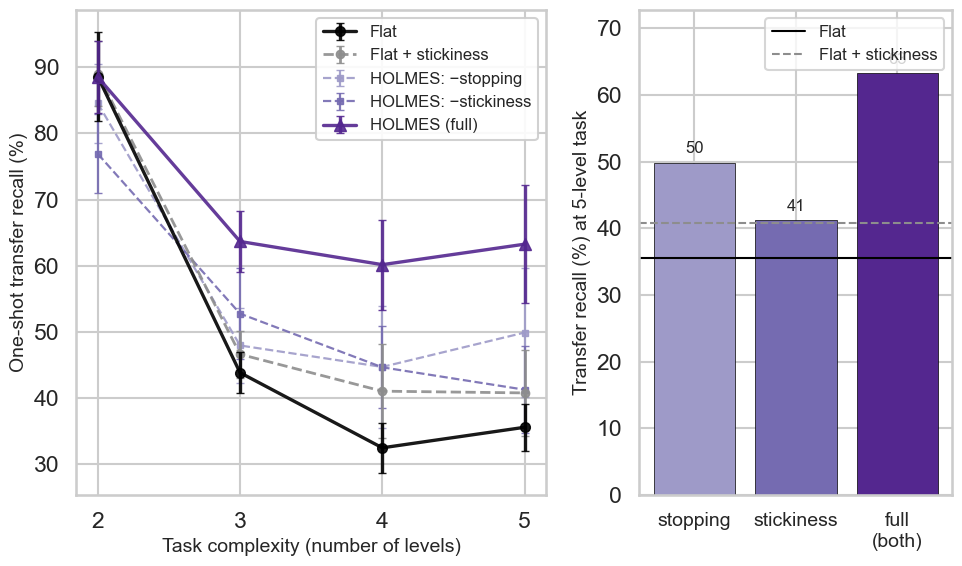

In [16]:
# display order + styling: two flat sims (grey/black), four HOLMES (purple ramp)
ORDER  = ["flat", "flat_sticky", 
          "holmes_no_stop", "holmes_no_stick", "holmes_full"]
LABEL  = {"flat": "Flat", "flat_sticky": "Flat + stickiness",
          
          "holmes_no_stop": "HOLMES: \u2212stopping",
          "holmes_no_stick": "HOLMES: \u2212stickiness",
          "holmes_full": "HOLMES (full)"}
COLOR  = {"flat": "#000000", "flat_sticky": "#8d8d8d",          # flat pair: black + grey
                              # purple ramp, light -> dark
          "holmes_no_stop": "#9e9ac8",
          "holmes_no_stick": "#756bb1",
          "holmes_full": "#54278f"}
STYLE  = {"flat":        dict(marker="o", ls="-",  lw=2.4, ms=7, zorder=5),
          "flat_sticky": dict(marker="o", ls="--", lw=2.0, ms=6, zorder=4),
          "holmes_full": dict(marker="^", ls="-",  lw=2.4, ms=8, zorder=5)}
DEFAULT = dict(marker="s", ls="--", lw=1.6, ms=5, alpha=0.9, zorder=3)

levels = sorted(cell_means["n_levels"].unique())

fig, (axL, axR) = plt.subplots(1, 2, figsize=(10, 6),
                               gridspec_kw={"width_ratios": [1.5, 1]})

# ---- Left: recall vs task complexity, all six variants ----
for v in ORDER:
    sub = panelB[panelB.variant == v].set_index("n_levels").reindex(levels)
    style = dict(DEFAULT)
    style.update(STYLE.get(v, {}))
    style.setdefault("color", COLOR[v])
    axL.errorbar(levels, sub["mean"] * 100, yerr=sub["ci95"] * 100,
                 capsize=3, label=LABEL[v], **style)
axL.set_xlabel("Task complexity (number of levels)", fontsize=14)
axL.set_ylabel("One-shot transfer recall (%)", fontsize=14)
#axL.set_title("(deepest level; mean \u00b1 95% CI across parameter cells)", fontsize=18)
axL.set_xticks(levels)
axL.legend(fontsize=12, loc="upper right", framealpha=0.9)

fig.subplots_adjust(wspace=3)
# ---- Right: decomposition at the deepest task, relative to structure-only ----
deep = max(levels)
d = panelB[panelB.n_levels == deep].set_index("variant")["mean"] * 100
steps = ["holmes_no_stop", "holmes_no_stick", "holmes_full"]
xs = np.arange(len(steps))
vals = [d.get(s, np.nan) for s in steps]
axR.bar(xs, vals, color=[COLOR[s] for s in steps],
    edgecolor="black", linewidth=0.5)
axR.set_ylim(0, np.nanmax(vals) * 1.15)
if "flat" in d.index:
    axR.axhline(d["flat"], ls="-", c="#000000", lw=1.5, label="Flat")
if "flat_sticky" in d.index:
    axR.axhline(d["flat_sticky"], ls="--", c="#8d8d8d", lw=1.5, label="Flat + stickiness")
axR.set_xticks(xs)
axR.set_xticklabels([ "stopping", "stickiness", "full\n(both)"],
                    fontsize=14)
axR.set_ylabel(f"Transfer recall (%) at {deep}-level task", fontsize=14)
#axR.set_title("Each mechanism's contribution", fontsize=18)
axR.legend(fontsize=12)
for x, s in zip(xs, steps):
    val = d.get(s, np.nan)
    if np.isfinite(val):
        axR.text(x, val + 1, f"{val:.0f}", ha="center", va="bottom", fontsize=12)

fig.tight_layout()

plt.show()

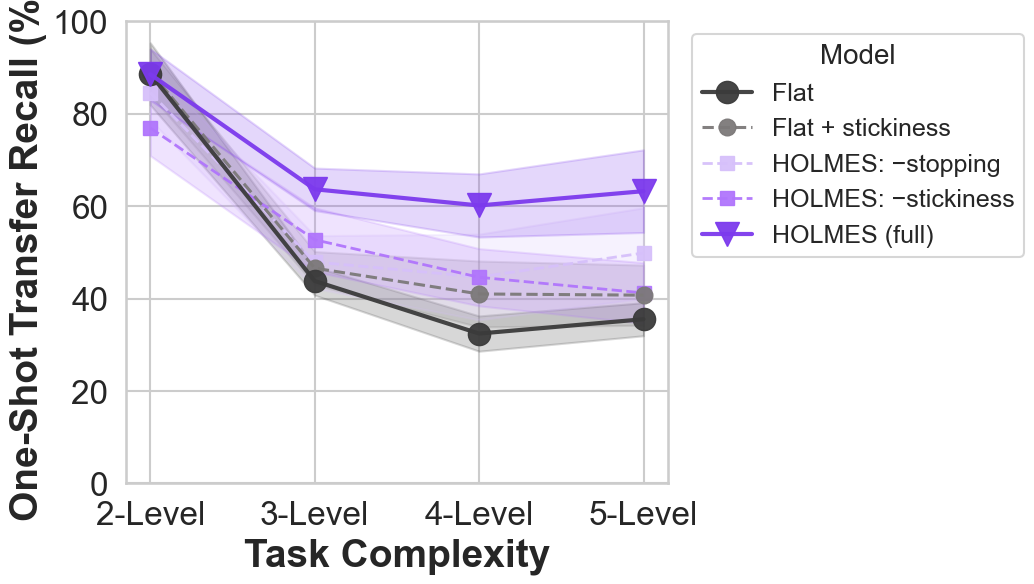

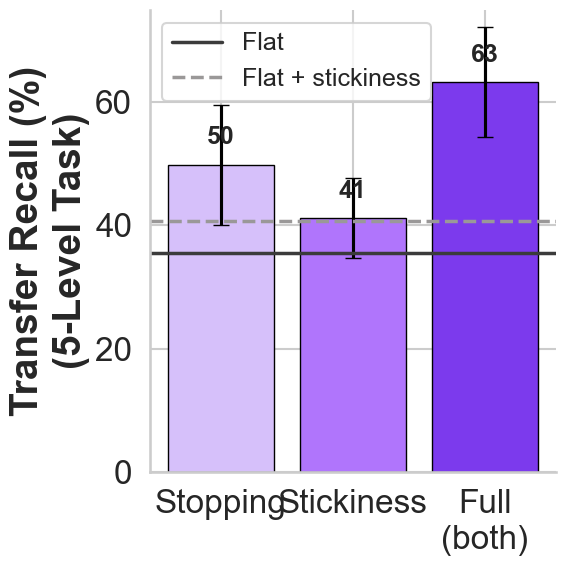

In [20]:

def ci95(x):
    x = x.dropna()
    return 1.96 * x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan

panelB = (cell_means.groupby(["variant", "n_levels"])["recall"]
          .agg(mean="mean", ci95=ci95, n="count").reset_index())

# ---- paper palette: flat pair anchored on COLOR_FLAT, HOLMES on a purple ramp
#      built around the paper's COLOR_HIER (#7C3AED) ----
COLOR_FLAT = "#3B3B3B"
COLOR_HIER = "#7C3AED"

ORDER  = ["flat", "flat_sticky",
          "holmes_no_stop", "holmes_no_stick", "holmes_full"]
LABEL  = {"flat": "Flat", "flat_sticky": "Flat + stickiness",
          "holmes_no_stop": "HOLMES: \u2212stopping",
          "holmes_no_stick": "HOLMES: \u2212stickiness",
          "holmes_full": "HOLMES (full)"}
COLOR  = {"flat": COLOR_FLAT, "flat_sticky": "#7C7979",          # flat pair: dark + grey                      # light -> dark purple
          "holmes_no_stop":     "#D6C0FA",
          "holmes_no_stick":    "#B075FC",
          "holmes_full":        COLOR_HIER}
# marker/line per variant; flat & holmes_full emphasized like the paper's main lines
STYLE  = {"flat":        dict(marker="o", ls="-",  lw=3,   ms=16, zorder=6),
          "flat_sticky": dict(marker="o", ls="--", lw=2.2, ms=12, zorder=4),
          "holmes_full": dict(marker="v", ls="-",  lw=3,   ms=17, zorder=6)}
DEFAULT = dict(marker="s", ls="--", lw=2, ms=10, alpha=0.95, zorder=3)

levels = np.array(sorted(cell_means["n_levels"].unique()))

sns.set_style("whitegrid")
sns.set_context("talk")

# fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 9),
#                                gridspec_kw={"width_ratios": [1.5, 1]})
figL, axL = plt.subplots(figsize=(7, 6))
# ---- Left: recall vs task complexity, all six variants (shaded CI bands) ----
for v in ORDER:
    sub = panelB[panelB.variant == v].set_index("n_levels").reindex(levels)
    m = sub["mean"].values * 100
    e = sub["ci95"].values * 100
    st = {**DEFAULT, **STYLE.get(v, {})}
    axL.fill_between(levels, m - e, m + e, color=COLOR[v], alpha=0.20, label="_nolegend_")
    axL.plot(levels, m, color=COLOR[v], label=LABEL[v], **st)

axL.set_xticks(levels)
axL.set_xticklabels([f"{n}-Level" for n in levels])
axL.set_xlabel("Task Complexity", fontsize=28, fontweight="bold")
axL.set_ylabel("One-Shot Transfer Recall (%)", fontsize=28, fontweight="bold")
axL.tick_params(axis="both", labelsize=24)
axL.set_ylim([0, 100])
axL.legend(title="Model", fontsize=18, title_fontsize=20,
           frameon=True, loc="upper left", bbox_to_anchor=(1.02, 1))

figR, axR = plt.subplots(figsize=(6, 6))
# ---- Right: mechanism decomposition at the deepest task ----
deep = int(levels.max())
d = panelB[panelB.n_levels == deep].set_index("variant")["mean"] * 100
e = panelB[panelB.n_levels == deep].set_index("variant")["ci95"] * 100
steps = [ "holmes_no_stop", "holmes_no_stick", "holmes_full"]
xs = np.arange(len(steps))
axR.bar(xs, [d.get(s, np.nan) for s in steps],
        yerr=[e.get(s, np.nan) for s in steps], capsize=6,
        color=[COLOR[s] for s in steps], edgecolor="black", linewidth=1)
if "flat" in d.index:
    axR.axhline(d["flat"], ls="-", c=COLOR_FLAT, lw=2.5, label="Flat")
if "flat_sticky" in d.index:
    axR.axhline(d["flat_sticky"], ls="--", c="#9A9898", lw=2.5, label="Flat + stickiness")
axR.set_xticks(xs)
axR.set_xticklabels(["Stopping", "Stickiness", "Full\n(both)"], fontsize=20)
axR.set_ylabel(f"Transfer Recall (%)\n({deep}-Level Task)", fontsize=28, fontweight="bold")
axR.tick_params(axis="both", labelsize=24)
axR.set_ylim([0, 75])
axR.legend(fontsize=18, frameon=True, loc="upper left")
for x, s in zip(xs, steps):
    val = d.get(s, np.nan)
    if np.isfinite(val):
        axR.text(x, val + 2.5, f"{val:.0f}", ha="center", va="bottom",
                 fontsize=18, fontweight="bold")

sns.despine()
plt.tight_layout()
plt.show()

In [6]:
# =====================================================================
# Ablation suite, task config matched exactly to the parameter sweep
# (shape_color_sweep_20260611_2009_per_seed.csv), not the main-text
# single-config run. Key differences from the earlier main-text ablation
# cell: reward_rule='random_balanced' (not 'shape0'), train_reps=10 and
# test_reps=3 (not 5/1), shape_copies=6 / color_copies=1 (unchanged).
# =====================================================================

import ablation_rule_task as rule_tps
import numpy as np
import pandas as pd

RULE_SEEDS = list(range(10))
N_PARTICLES = 200

ALPHA = 0.3
OMEGA = 0.1
MAX_DEPTH = 20
MAX_CHILDREN = 20
LENGTH_NORMALIZE = True
TAU = 1.0

HIER_STICKINESS = OMEGA
FLAT_STICKINESS = OMEGA

# match the sweep file's task config from main tect
rule_cfg = rule_tps.ShapeColorConfig(
    n_colors=10, n_train_colors=8, n_test_colors=2,
    train_reps_per_stimulus=10, test_reps_per_stimulus=3,
    n_shape_copies=6, n_color_copies=1, n_nuisance_features=0,
    blocked_train_by_shape=True, shuffle_within_train_blocks=True,
    shuffle_test=True, reward_rule="random_balanced",
)

rule_rows = []
for seed in RULE_SEEDS:
    if seed % 5 == 0:
        print(f"Running rule-task ablation (sweep config), seed {seed} ...")
    df_seed = rule_tps.run_one_seed(
        seed, rule_cfg, N_PARTICLES, ALPHA, OMEGA,
        MAX_DEPTH, MAX_CHILDREN, LENGTH_NORMALIZE, TAU,
        HIER_STICKINESS, FLAT_STICKINESS,
    )
    rule_rows.append(df_seed)

rule_df_sweepcfg = pd.concat(rule_rows, ignore_index=True)
print(f"\nCollected {len(rule_df_sweepcfg)} (seed, variant) rows across {len(RULE_SEEDS)} seeds.")

# ---- Aggregate mean +/- 95% CI per variant ----
def ci95(x):
    x = x.dropna()
    return 1.96 * x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan

rule_summary_sweepcfg = (rule_df_sweepcfg.groupby("variant")["first_heldout_acc"]
                          .agg(mean="mean", ci95=ci95, n="count")
                          .reindex(rule_tps.VARIANT_ORDER))
rule_summary_sweepcfg["mean_pct"] = (rule_summary_sweepcfg["mean"] * 100).round(1)
rule_summary_sweepcfg["ci95_pct"] = (rule_summary_sweepcfg["ci95"] * 100).round(1)

print("\nRule-task first-heldout accuracy (%, mean +/- 95% CI, sweep task config):")
print(rule_summary_sweepcfg[["mean_pct", "ci95_pct", "n"]].to_string())

d = rule_summary_sweepcfg["mean"]


Running rule-task ablation (sweep config), seed 0 ...
Running rule-task ablation (sweep config), seed 5 ...

Collected 50 (seed, variant) rows across 10 seeds.

Rule-task first-heldout accuracy (%, mean +/- 95% CI, sweep task config):
                 mean_pct  ci95_pct   n
variant                                
flat                 55.0       9.8  10
flat_sticky          47.5      13.6  10
holmes_no_stop       75.0      19.3  10
holmes_no_stick      92.5       7.5  10
holmes_full         100.0       0.0  10


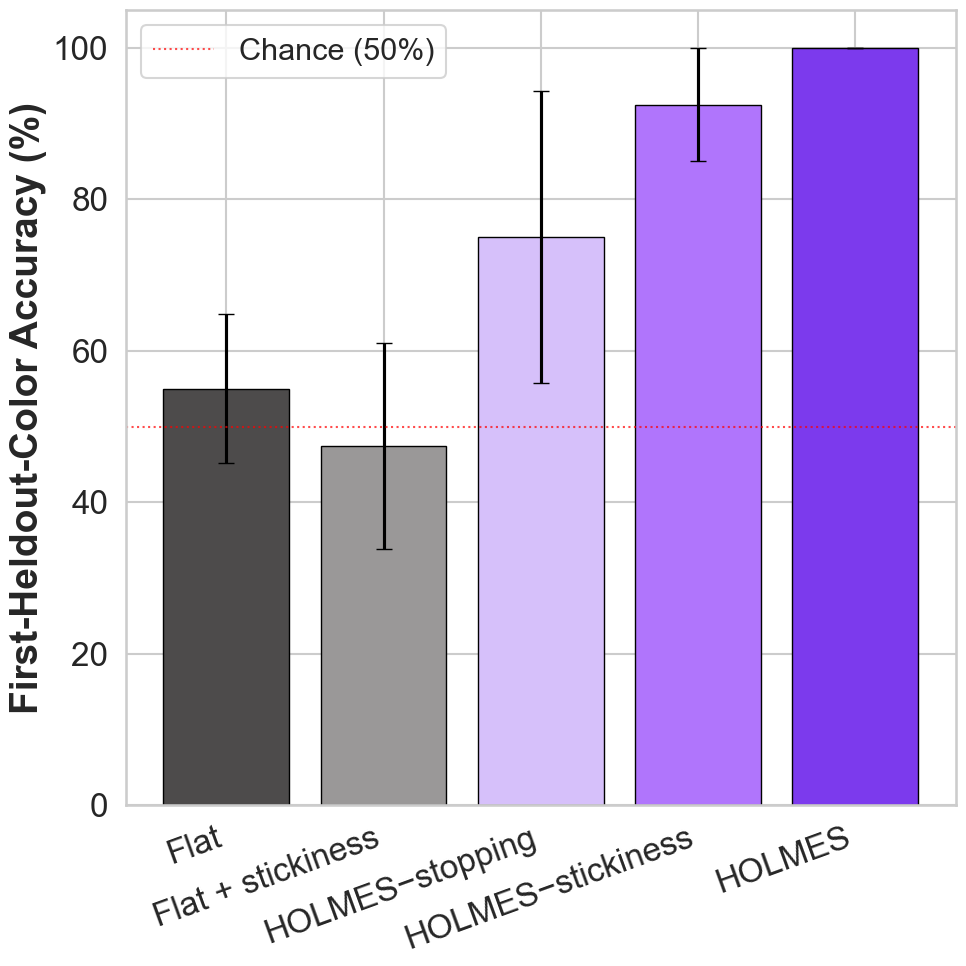

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt


# =====================================================================
# Plot: two separate figures instead of one 2-panel layout
# =====================================================================
COLOR_FLAT = "#4D4B4B"
COLOR_HIER = "#7C3AED"

LABEL = {
    "flat": "Flat",
    "flat_sticky": "Flat + stickiness",
    "holmes_no_stop": "HOLMES−stopping",
    "holmes_no_stick": "HOLMES−stickiness",
    "holmes_full": "HOLMES",
}
COLOR = {
    "flat": COLOR_FLAT,
    "flat_sticky": "#9A9898",
    "holmes_no_stop": "#D6C0FA",
    "holmes_no_stick": "#B075FC",
    "holmes_full": COLOR_HIER,
}

sns.set_style("whitegrid")
sns.set_context("talk")

order = rule_tps.VARIANT_ORDER
means = rule_summary_sweepcfg.loc[order, "mean_pct"].values
errs = rule_summary_sweepcfg.loc[order, "ci95_pct"].values
colors = [COLOR[v] for v in order]
labels = [LABEL[v] for v in order]

xs = np.arange(len(order))

fig1, ax1 = plt.subplots(figsize=(10, 10))
ax1.bar(xs, means, yerr=errs, capsize=6, color=colors, edgecolor="black", linewidth=1)
ax1.axhline(50, ls=":", c="red", lw=1.5, alpha=0.7, label="Chance (50%)")
ax1.set_xticks(xs)
ax1.set_xticklabels(labels, rotation=20, ha="right", fontsize=24)
ax1.set_ylabel("First-Heldout-Color Accuracy (%)", fontsize=28, fontweight="bold")
#ax1.set_title("Sweep task config (balanced rule)", fontsize=16)
ax1.set_ylim([0, 105])
ax1.tick_params(axis="y", labelsize=24)
ax1.legend(fontsize=22, loc="upper left")

# for x, m in zip(xs, means):
#     if np.isfinite(m):
#         ax1.text(x, m + 2, f"{m:.0f}", ha="center", va="bottom", fontsize=18, fontweight="bold")

fig1.tight_layout()
plt.show()